In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pass_rusher_attention_overall = pd.read_csv("../Data Cleaning + Engineering/outputs_csv/player_attention_scores.csv")
each_pass_rusher = pd.read_csv("../Data Cleaning + Engineering/outputs_csv/each_pass_rusher.csv")

In [2]:
all_rushers = (
    each_pass_rusher
    .rename(columns={"nflId": "rusher_nflId", "displayName": "rusher_name"})
    .drop_duplicates()
).drop_duplicates(subset=['gameId','playId','rusher_nflId']).groupby(["rusher_nflId", "rusher_name"], as_index=False).agg(
        num_plays=("playId", "count")
    )
all_rushers

,rusher_nflId,rusher_name,num_plays
0,33131,Calais Campbell,169
1,34465,Malcolm Jenkins,24
2,34654,Jason McCourty,3
3,34777,Steve McLendon,43
4,35441,Ndamukong Suh,183
...,...,...,...
680,53935,Darius Hodge,4
681,53957,A.J. Parker,10
682,53978,Austin Faoliu,10
683,53991,Forrest Merrill,2


In [3]:
pass_rusher_attention_overall

,rusher_nflId,player_attention_score,rusher_name
0,48462,1.751414,Kevin Strong
1,53618,1.739999,Marlon Tuipulotu
2,43411,1.738792,Andrew Billings
3,48520,1.711538,Anthony Rush
4,46504,1.634177,Daniel Ekuale
...,...,...,...
680,52939,0.000000,Sam Franklin
681,43366,0.000000,Daryl Worley
682,53521,0.000000,Monty Rice
683,42389,0.000000,Jaquiski Tartt


In [4]:
pass_rusher_attention_overall=pass_rusher_attention_overall.merge(
    all_rushers,
    on=["rusher_nflId",'rusher_name'],
    how="left",
    validate="one_to_one"
).rename(columns={'player_attention_score':'avg_attention_across_plays'})

In [5]:
pass_rusher_attention_overall_50_plus = (
    pass_rusher_attention_overall[
        pass_rusher_attention_overall["num_plays"] >= 50
    ]
    .sort_values(
        ["avg_attention_across_plays", "num_plays"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

In [6]:
players = pd.read_csv("../Data Cleaning + Engineering/cleaned_csv/players_cleaned.csv")

# Add blocker_position and rusher_position from players using officialPosition
player_positions = players[
    ['nflId', 'officialPosition']
].drop_duplicates(subset=['nflId'])



pass_rusher_attention_overall_50_plus = pass_rusher_attention_overall_50_plus.merge(
    player_positions.rename(columns={
        'nflId': 'rusher_nflId',
        'officialPosition': 'rusher_position'
    }),
    on='rusher_nflId',
    how='left'
)

In [7]:
pass_rusher_attention_overall_50_plus

,rusher_nflId,avg_attention_across_plays,rusher_name,num_plays,rusher_position
0,53467,1.612486,Christian Barmore,165,DT
1,37308,1.594103,Lawrence Guy,61,DT
2,41239,1.590982,Aaron Donald,229,DT
3,52455,1.576065,Marlon Davidson,50,DT
4,46249,1.543350,Folorunso Fatukasi,102,DT
...,...,...,...,...,...
219,48089,0.803946,Malik Reed,183,OLB
220,52492,0.782586,Terrell Lewis,136,OLB
221,52428,0.755497,K'Lavon Chaisson,50,OLB
222,47939,0.728201,Justin Hollins,64,OLB


In [9]:
# get number of duplicates in rusher_name column
pass_rusher_attention_overall_50_plus['rusher_name'].duplicated().sum()

0

## Merge with PFF data for positions such as DI, ED, LB, etc.

In [8]:
pff_2021 = pd.read_csv("../Data Cleaning + Engineering/cleaned_csv/pff_position_data.csv")
pff_2021

,player,player_id,position,team_name,player_game_count,assists,batted_passes,catch_rate,declined_penalties,forced_fumbles,...,snap_counts_slot,stops,tackles,tackles_for_loss,targets,total_pressures,touchdowns,yards,yards_after_catch,yards_per_reception
0,DeSean Jackson,4363,WR,LV,1,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0,NaN
1,Calais Campbell,4364,DI,BLT,15,12,1,NaN,1,0,...,0,24,34,6,0,31,0,0,0,NaN
2,Matthew Slater,4467,WR,NE,1,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0,NaN
3,Malcolm Jenkins,4937,S,NO,16,17,0,70.4,0,1,...,226,27,65,2,54,5,2,348,164,9.2
4,Jason McCourty,5127,S,MIA,7,5,0,71.4,0,0,...,25,3,16,0,14,0,1,98,29,9.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,Nahshon Wright,100412,CB,DAL,5,0,0,62.5,1,0,...,3,1,5,0,8,0,0,81,10,16.2
1113,Daniel Archibong,100963,DI,PIT,2,1,0,NaN,0,0,...,0,0,1,0,0,0,0,0,0,NaN
1114,Jarren Williams,101750,CB,NYG,5,2,0,47.1,0,0,...,46,5,14,0,17,0,1,64,19,8.0
1115,Michael Hoecht,108840,DI,LA,12,0,0,NaN,0,0,...,0,3,4,0,0,2,0,0,0,NaN


In [9]:
import pandas as pd
import re

# --------------------------------------------------
# 1. Helper: keep only the first two words of a name
#    Example:
#    "Lawrence Guy Sr." -> "lawrence guy"
#    "Takkarist McKinley" -> "takkarist mckinley"
# --------------------------------------------------
def first_two_words(name):
    if pd.isna(name):
        return None
    name = str(name).strip()
    if not name:
        return None

    # collapse repeated whitespace
    name = re.sub(r"\s+", " ", name)

    # keep only first two words
    words = name.split(" ")[:2]

    return " ".join(words).lower()


# --------------------------------------------------
# 2. Helper: compact version for containment matching
#    Example:
#    "Lawrence Guy" -> "lawrenceguy"
#    "Takk McKinley" -> "takkmckinley"
# --------------------------------------------------
def compact_name(name):
    if pd.isna(name):
        return None
    name = str(name).lower()

    # keep only letters/numbers, remove spaces/punctuation
    name = re.sub(r"[^a-z0-9]", "", name)

    return name if name else None


# --------------------------------------------------
# 3. Position mapping:
#    pff_2021['position'] -> allowed df['rusher_position']
# --------------------------------------------------
position_map = {
    "DI": ["DE", "DT", "NT"],
    "ED": ["DE", "OLB"],
    "LB": ["OLB", "ILB"]
}


# --------------------------------------------------
# 4. Make working copies
# --------------------------------------------------
df_work = pass_rusher_attention_overall_50_plus.copy().reset_index(drop=False).rename(columns={"index": "_row_id"})
pff_work = pff_2021[["player", "position", "team_name"]].copy()


# --------------------------------------------------
# 5. Normalize names in both dataframes
# --------------------------------------------------
df_work["rusher_name_2w"] = df_work["rusher_name"].apply(first_two_words)
df_work["rusher_name_compact"] = df_work["rusher_name_2w"].apply(compact_name)

pff_work["player_2w"] = pff_work["player"].apply(first_two_words)
pff_work["player_compact"] = pff_work["player_2w"].apply(compact_name)


# --------------------------------------------------
# 6. Expand PFF positions so each row has one allowed
#    df rusher position it can match to
# --------------------------------------------------
pff_work["allowed_rusher_position"] = pff_work["position"].map(position_map)
pff_expanded = pff_work.explode("allowed_rusher_position").reset_index(drop=True)


# --------------------------------------------------
# 7. Merge on position first
#    This gives candidate matches only where the custom
#    position logic is satisfied
# --------------------------------------------------
candidates = df_work.merge(
    pff_expanded,
    how="left",
    left_on="rusher_position",
    right_on="allowed_rusher_position",
    suffixes=("", "_pff")
)


# --------------------------------------------------
# 8. Apply custom name matching
#
#    A match is TRUE if:
#    (a) first two words are exactly equal
#        OR
#    (b) word-by-word subsequence matching works in either direction
#
#    This handles:
#    "Lawrence Guy Sr." vs "Lawrence Guy"
#    "Takkarist McKinley" vs "Takk McKinley"
# --------------------------------------------------
def is_subsequence(small, big):
    """
    Return True if every character in `small` appears in `big`
    in the same left-to-right order (not necessarily contiguously).
    Example:
        'takk' in-order within 'takkarist' -> True
    """
    if small is None or big is None:
        return False

    i = 0
    for ch in big:
        if i < len(small) and ch == small[i]:
            i += 1
    return i == len(small)


def names_match_two_word_logic(name1, name2):
    """
    Compare the first two words of each normalized name.
    Match if:
      1) exact equality, OR
      2) each corresponding word matches by subsequence in either direction
    """
    if pd.isna(name1) or pd.isna(name2):
        return False

    name1 = str(name1).strip().lower()
    name2 = str(name2).strip().lower()

    if not name1 or not name2:
        return False

    # exact match on the normalized first-two-word strings
    if name1 == name2:
        return True

    words1 = name1.split()
    words2 = name2.split()

    # require same number of words after first_two_words normalization
    if len(words1) != len(words2):
        return False

    # each corresponding word must match by subsequence in either direction
    for w1, w2 in zip(words1, words2):
        if not (is_subsequence(w1, w2) or is_subsequence(w2, w1)):
            return False

    return True


candidates["name_match"] = candidates.apply(
    lambda x: names_match_two_word_logic(x["rusher_name_2w"], x["player_2w"]),
    axis=1
)

# Keep only rows where the custom name rule matched
matched = candidates[candidates["name_match"]].copy()


# --------------------------------------------------
# 9. If multiple PFF rows match the same df row,
#    choose the best one:
#    - exact two-word match beats containment match
#    - then smaller compact-name length difference wins
# --------------------------------------------------
matched["match_score"] = 1
matched.loc[matched["rusher_name_2w"] == matched["player_2w"], "match_score"] = 2

matched["length_diff"] = (
    matched["rusher_name_compact"].str.len()
    - matched["player_compact"].str.len()
).abs()

best_match = (
    matched.sort_values(
        by=["_row_id", "match_score", "length_diff"],
        ascending=[True, False, True]
    )
    .drop_duplicates(subset="_row_id", keep="first")
    [["_row_id", "player", "position", "team_name"]]
)


# --------------------------------------------------
# 10. Merge the selected PFF columns back into df
# --------------------------------------------------
df_merged = df_work.merge(best_match, on="_row_id", how="left")


# --------------------------------------------------
# 11. Drop helper columns if you do not want them
# --------------------------------------------------
df_merged = df_merged.drop(
    columns=["_row_id", "rusher_name_2w", "rusher_name_compact"]
)

# df_merged is your final dataframe

In [10]:
df_merged[df_merged["position"].isna()]

,rusher_nflId,avg_attention_across_plays,rusher_name,num_plays,rusher_position,player,position,team_name
68,52479,1.411025,Justin Madubuike,75,DT,NaN,NaN,NaN
83,40171,1.383278,Nicholas Williams,112,DE,NaN,NaN,NaN
151,52585,1.004988,Michael Danna,137,DE,NaN,NaN,NaN


In [11]:
# Handle outliers
df_merged.loc[
    df_merged["rusher_name"] == "Michael Danna",
    ["player", "position", "team_name"]
] = (
    pff_expanded.loc[
        pff_expanded["player"] == "Mike Danna",
        ["player", "position", "team_name"]
    ].iloc[0].values
)

df_merged.loc[
    df_merged["rusher_name"] == "Nicholas Williams",
    ["player", "position", "team_name"]
] = (
    pff_expanded.loc[
        pff_expanded["player"] == "Nick Williams",
        ["player", "position", "team_name"]
    ].iloc[0].values
)

df_merged.loc[
    df_merged["rusher_name"] == "Justin Madubuike",
    ["player", "position", "team_name"]
] = (
    pff_expanded.loc[
        pff_expanded["player"] == "Nnamdi Madubuike",
        ["player", "position", "team_name"]
    ].iloc[0].values
)




In [12]:
# min of 100 plays
df_merged=df_merged[df_merged['num_plays'] >= 100]

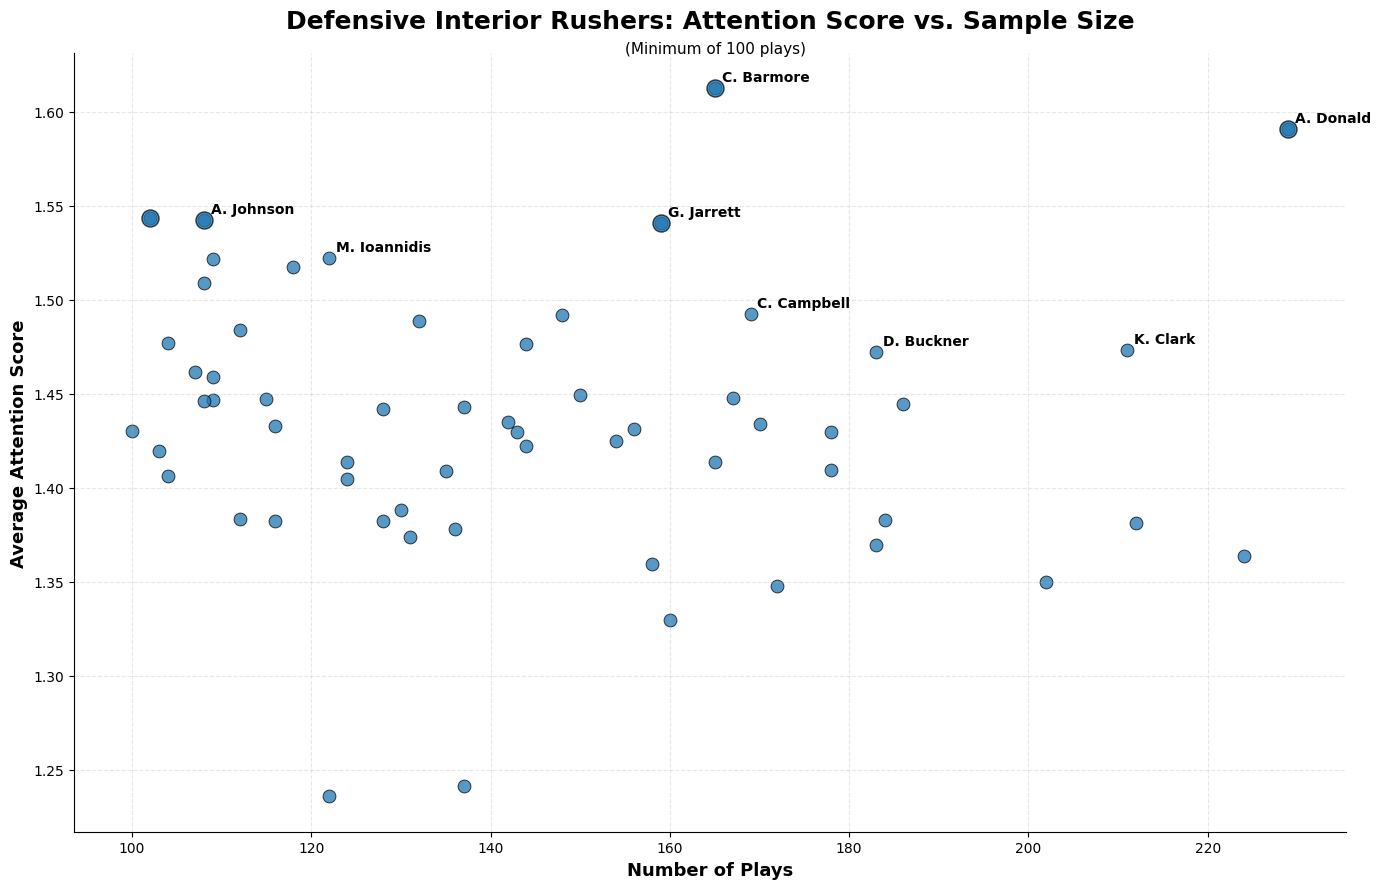

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Filter to DI rushers and keep needed cols
# --------------------------------------------
plot_df = (
    df_merged[df_merged["position"] == "DI"][
        ["rusher_name", "num_plays", "avg_attention_across_plays"]
    ]
    .dropna(subset=["rusher_name", "num_plays", "avg_attention_across_plays"])
    .copy()
)

# --------------------------------------------
# 2. Get top 5 by avg_attention_across_plays
# --------------------------------------------
top_5 = (
    plot_df.sort_values("avg_attention_across_plays", ascending=False)
    .head(5)
    .copy()
)

# --------------------------------------------
# 3. Create Big Data Bowl-style scatter plot
# --------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))

# Main scatter
ax.scatter(
    plot_df["num_plays"],
    plot_df["avg_attention_across_plays"],
    s=85,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.7,
    color="tab:blue"
)

# Highlight top 5 with same color, just bigger
ax.scatter(
    top_5["num_plays"],
    top_5["avg_attention_across_plays"],
    s=150,
    alpha=0.75,
    edgecolors="black",
    linewidths=1.0,
    color="tab:blue",
    zorder=3
)

# --------------------------------------------
# 4. Add labels
#    - label top 5 EXCEPT Folorunso Fatukasi
#    - also force labels for specific players
# --------------------------------------------
forced_labels = {
    "Kenny Clark",
    "DeForest Buckner",
    "Calais Campbell",
    "Matt Ioannidis"
}

top_5_names = set(top_5["rusher_name"])
excluded_names = {"Folorunso Fatukasi"}

label_names = (top_5_names - excluded_names) | forced_labels

label_df = plot_df[plot_df["rusher_name"].isin(label_names)].copy()

for _, row in label_df.iterrows():
    first_name, *rest = row["rusher_name"].split()
    abbreviated_name = f"{first_name[0]}. {' '.join(rest)}"

    ax.annotate(
        abbreviated_name,
        xy=(row["num_plays"], row["avg_attention_across_plays"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

# --------------------------------------------
# 5. Styling
# --------------------------------------------
ax.set_title(
    "Defensive Interior Rushers: Attention Score vs. Sample Size",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Number of Plays", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Attention Score", fontsize=13, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.45,
    0.934,
    "(Minimum of 100 plays)",
    fontsize=11
)

plt.tight_layout()
plt.show()

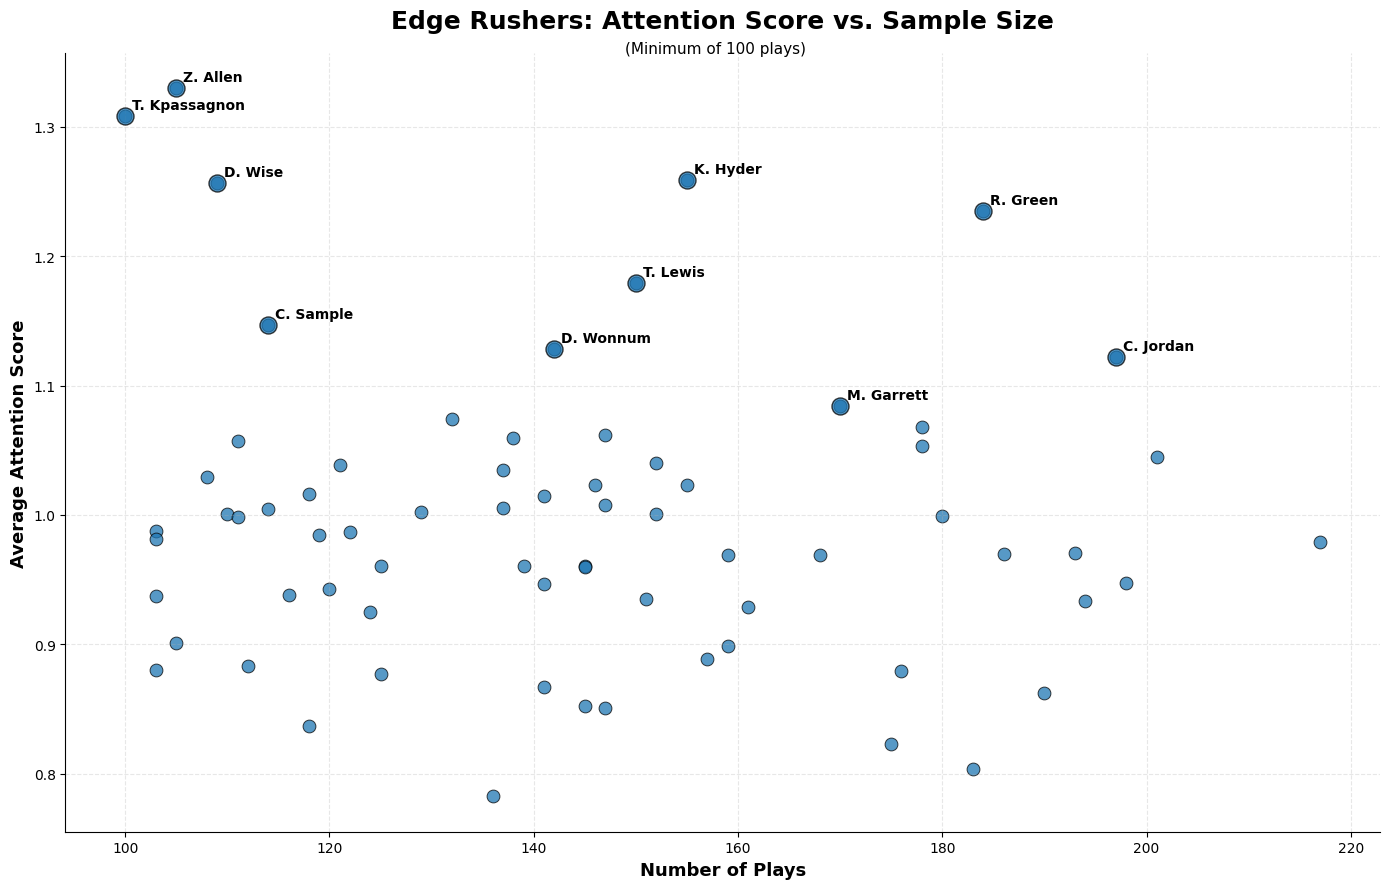

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Filter to DI rushers and keep needed cols
# --------------------------------------------
plot_df = (
    df_merged[df_merged["position"] == "ED"][
        ["rusher_name", "num_plays", "avg_attention_across_plays"]
    ]
    .dropna(subset=["rusher_name", "num_plays", "avg_attention_across_plays"])
    .copy()
)

# --------------------------------------------
# 2. Get top 5 by avg_attention_across_plays
# --------------------------------------------
top_10 = (
    plot_df.sort_values("avg_attention_across_plays", ascending=False)
    .head(10)
    .copy()
)

# --------------------------------------------
# 3. Create Big Data Bowl-style scatter plot
# --------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))

# Main scatter
ax.scatter(
    plot_df["num_plays"],
    plot_df["avg_attention_across_plays"],
    s=85,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.7,
    color="tab:blue"
)

# Highlight top 5 with same color, just bigger
ax.scatter(
    top_10["num_plays"],
    top_10["avg_attention_across_plays"],
    s=150,
    alpha=0.75,
    edgecolors="black",
    linewidths=1.0,
    color="tab:blue",
    zorder=3
)

# --------------------------------------------
# 4. Add labels for top 5 players
# --------------------------------------------
for _, row in top_10.iterrows():
    first_name, *rest = row["rusher_name"].split()
    abbreviated_name = f"{first_name[0]}. {' '.join(rest)}"

    ax.annotate(
        abbreviated_name,
        xy=(row["num_plays"], row["avg_attention_across_plays"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

# --------------------------------------------
# 5. Styling
# --------------------------------------------
ax.set_title(
    "Edge Rushers: Attention Score vs. Sample Size",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Number of Plays", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Attention Score", fontsize=13, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.45,
    0.934,
    "(Minimum of 100 plays)",
    fontsize=11
)


plt.tight_layout()
plt.show()